# ABM Crime Propensity Modeling with XGBoost

This notebook prepares the hourly modeling dataset and compares several **XGBoost regression models** for predicting a continuous crime propensity target.

## Goal

The model is **not** predicting whether a crime happened as a binary classification problem. Instead, it predicts a **continuous multiplier / probability adjustment** that will later be combined with the baseline probability inside the ABM:

\[
P_{final} = \text{clip}(P_{baseline} \times \exp(\hat{y}), 0, 1)
\]

where:

- `P_baseline` comes from the precomputed station/day/hour baseline table
- `\hat{y}` is the model prediction for `target_log_multiplier`

Then the simulation will draw a random number at each step:

\[
u \sim Uniform(0,1), \quad crime\_occurs = (u < P_{final})
\]

## Models compared

1. **Contextual model**: environmental and temporal features only
2. **Context + location model**: adds station and spatial context
3. **Fast / shallow model**: lower complexity option intended to be more efficient during repeated ABM predictions

## Important note

The hard CMPD deterrence rule should be applied **outside** the model:

```python
if distance_to_nearest_cmpd <= CMPD_BLOCK_RADIUS:
    p_final = 0.0
```

That rule should override the model at simulation time.

In [142]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor, plot_importance

In [143]:
# File paths
MODELING_FILE = "model/modeling_dataset_hourly.csv"
BASELINE_FILE = "model/baseline_station_day_hour_probabilities.csv"

df = pd.read_csv(MODELING_FILE)
baseline = pd.read_csv(BASELINE_FILE)

print("Modeling dataset shape:", df.shape)
print("Baseline dataset shape:", baseline.shape)
df.head()

Modeling dataset shape: (34104, 43)
Baseline dataset shape: (576, 11)


,centroid_id,date_only,hour,day_type,nearest_station,crime_count,temp,tempmax,tempmin,precip,...,expected_hourly_crimes,station_weight,crime_share,ridership_share,baseline_expected_count,target_rate,target_multiplier,target_log_multiplier,baseline_prob_clipped,baseline_logit
0,0,2017-02-07,18,Weekday,East/West,1,59.9,72.0,48.3,0.015,...,0.414276,0.902792,0.115789,0.10403,0.414276,1,2.413848,0.346529,0.339182,-0.666943
1,0,2017-07-07,18,Weekday,East/West,1,81.1,89.2,73.3,0.000,...,0.414276,0.902792,0.115789,0.10403,0.414276,1,2.413848,0.346529,0.339182,-0.666943
2,0,2017-12-13,14,Weekday,East/West,1,37.0,47.1,26.6,0.000,...,0.555439,0.902792,0.115789,0.10403,0.555439,1,1.800378,0.251389,0.426180,-0.297455
3,0,2018-02-19,2,Weekday,East/West,1,53.1,56.7,50.1,0.131,...,0.363880,0.902792,0.115789,0.10403,0.363880,1,2.748156,0.382813,0.305026,-0.823479
4,0,2018-05-22,16,Weekday,East/West,1,75.5,84.9,66.7,0.078,...,0.497728,0.902792,0.115789,0.10403,0.497728,1,2.009131,0.289198,0.392089,-0.438538


## Initial checks

These checks make sure the target and core features are present and inspect missing values before modeling.

In [144]:
# Parse dates
df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")

# Quick structure checks
print(df.dtypes.sort_index())
print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nTarget summary:")
display(df["target_log_multiplier"].describe())

baseline_expected_count                    float64
baseline_logit                             float64
baseline_prob                              float64
baseline_prob_clipped                      float64
centroid_id                                  int64
cloudcover                                 float64
crime_count                                  int64
crime_share                                float64
date_only                           datetime64[us]
day_type                                       str
env_within_10m                             float64
env_within_25m                             float64
env_within_50m                             float64
expected_hourly_crimes                     float64
hour                                         int64
hour_cos                                   float64
hour_sin                                   float64
humidity                                   float64
lat                                        float64
lon                            

centroid_id            0
date_only              0
hour                   0
day_type               0
nearest_station        0
crime_count            0
temp                   0
tempmax                0
tempmin                0
precip                 0
precipcover            0
cloudcover             0
humidity               0
windspeed              0
visibility             0
snow                   0
nearest_tree_dist_m    0
trees_within_10m       0
trees_within_25m       0
trees_within_50m       0
dtype: int64


Target summary:


count    34104.000000
mean         0.185142
std          0.285333
min         -0.353917
25%         -0.086037
50%          0.290780
75%          0.389068
max          1.851744
Name: target_log_multiplier, dtype: float64

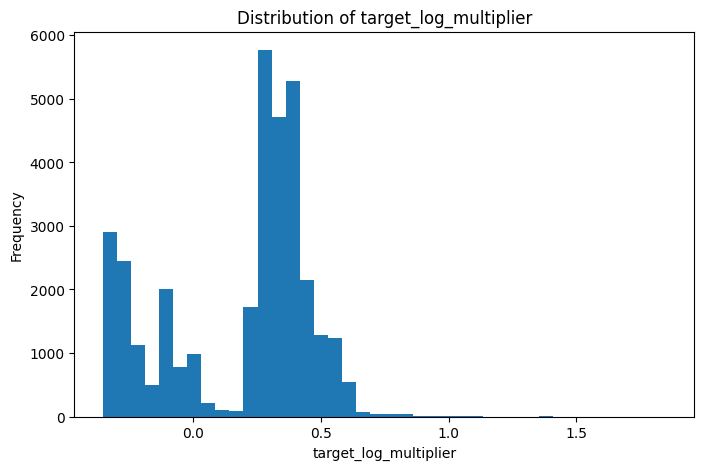

In [145]:
# Distribution of the main regression target
plt.figure(figsize=(8, 5))
plt.hist(df["target_log_multiplier"].dropna(), bins=40)
plt.xlabel("target_log_multiplier")
plt.ylabel("Frequency")
plt.title("Distribution of target_log_multiplier")
plt.show()

## Additional preparation for modeling

This section performs the final preparation needed before fitting XGBoost:

- removes rows missing the target
- creates a few extra calendar features
- excludes direct target leakage columns
- uses a **time-based split** instead of a random split

In [146]:
# Remove rows with missing target or date
df = df.dropna(subset=["target_log_multiplier", "date_only"]).copy()

# Extra time features
df["month"] = df["date_only"].dt.month
df["day"] = df["date_only"].dt.day
df["dayofweek"] = df["date_only"].dt.dayofweek
df["year_num"] = df["date_only"].dt.year

# Keep hour as numeric; cyclical hour_sin/hour_cos already exist
# Standardize string categorical columns
for col in ["day_type", "nearest_station"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

print("Rows after dropping missing target/date:", len(df))

Rows after dropping missing target/date: 34104


## Leakage control

Because the target is already derived from the baseline, we should be careful about what goes into the model.

The following columns are **not used as predictors**:

- raw target columns
- exact baseline terms used to construct the target
- date field itself
- count field that directly encodes the realized outcome

In [147]:
target_col = "target_log_multiplier"

leakage_cols = [
    "target_log_multiplier",
    "target_multiplier",
    "target_rate",
    "crime_count",
    "baseline_expected_count",
    "baseline_prob",
    "baseline_logit",
]

id_or_nonpredictive_cols = [
    "date_only",
]

# Contextual features: environmental + temporal
context_features = [
    "hour", "month", "day", "dayofweek", "year_num",
    "temp", "tempmax", "tempmin", "precip", "precipcover", "cloudcover",
    "humidity", "windspeed", "visibility", "snow",
    "nearest_tree_dist_m", "trees_within_10m", "trees_within_25m", "trees_within_50m",
    "env_within_10m", "env_within_25m", "env_within_50m",
    "min_station_dist_m", "mean_station_dist_m", "num_stations_in_radius_from_list",
    "is_weekend", "day_type"
]

# Adds spatial/location context that may improve fit
location_features = context_features + [
    "nearest_station", "centroid_id", "lat", "lon",
    "station_overall_ridership", "ridership_weight_overall"
]

# A smaller faster feature set
fast_features = [
    "hour", "dayofweek",
    "temp", "precip", "cloudcover", "humidity", "windspeed",
    "trees_within_50m", "env_within_50m",
    "min_station_dist_m", "nearest_station", "day_type",
    "station_overall_ridership"
]

# Keep only columns that actually exist
context_features = [c for c in context_features if c in df.columns]
location_features = [c for c in location_features if c in df.columns]
fast_features = [c for c in fast_features if c in df.columns]

print("Context feature count:", len(context_features))
print("Location feature count:", len(location_features))
print("Fast feature count:", len(fast_features))

Context feature count: 26
Location feature count: 32
Fast feature count: 13


In [148]:
# Time-based split: train on earlier dates, test on later dates
split_date = df["date_only"].quantile(0.80)
train_df = df[df["date_only"] <= split_date].copy()
test_df = df[df["date_only"] > split_date].copy()

print("Split date:", split_date.date())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Split date: 2024-07-31
Train rows: 27289
Test rows: 6815


## Modeling helper functions

In [149]:
def build_preprocessor(feature_list, frame):
    numeric_features = [c for c in feature_list if pd.api.types.is_numeric_dtype(frame[c])]
    categorical_features = [c for c in feature_list if c not in numeric_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_features, categorical_features


def evaluate_regression(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "model": label,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def fit_xgb_model(train_df, test_df, feature_list, params, label):
    preprocessor, num_cols, cat_cols = build_preprocessor(feature_list, train_df)

    X_train = train_df[feature_list]
    y_train = train_df[target_col]
    X_test = test_df[feature_list]
    y_test = test_df[target_col]

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    model = XGBRegressor(**params)
    model.fit(X_train_t, y_train)

    preds = model.predict(X_test_t)

    metrics = evaluate_regression(y_test, preds, label)
    return {
        "label": label,
        "model": model,
        "preprocessor": preprocessor,
        "X_train_t": X_train_t,
        "X_test_t": X_test_t,
        "y_train": y_train,
        "y_test": y_test,
        "preds": preds,
        "metrics": metrics,
        "numeric_cols": num_cols,
        "categorical_cols": cat_cols,
        "features": feature_list,
    }

## Fit and compare XGBoost models

In [150]:
common_params = dict(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5, # To be changed
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

context_params = common_params.copy()

location_params = common_params.copy()
location_params.update({
    "max_depth": 6,
    "n_estimators": 400,
})

fast_params = common_params.copy()
fast_params.update({
    "n_estimators": 120,
    "max_depth": 5,
    "learning_rate": 0.08,
    "min_child_weight": 5,
})

In [151]:
context_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=context_features,
    params=context_params,
    label="XGB Contextual"
)

location_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=location_features,
    params=location_params,
    label="XGB Context + Location"
)

fast_result = fit_xgb_model(
    train_df=train_df,
    test_df=test_df,
    feature_list=fast_features,
    params=fast_params,
    label="XGB Fast/Shallow"
)

results_df = pd.DataFrame([
    context_result["metrics"],
    location_result["metrics"],
    fast_result["metrics"],
]).sort_values("rmse")

results_df

,model,rmse,mae,r2
2,XGB Fast/Shallow,0.053546,0.015666,0.964811
1,XGB Context + Location,0.055072,0.017185,0.962778
0,XGB Contextual,0.055148,0.019191,0.962675


Lower RMSE and MAE are better. Higher R² is better.

For the ABM, the best model is not automatically the one with the lowest error. You also care about:

- prediction speed
- ease of deployment inside the simulation loop
- stability under many repeated predictions

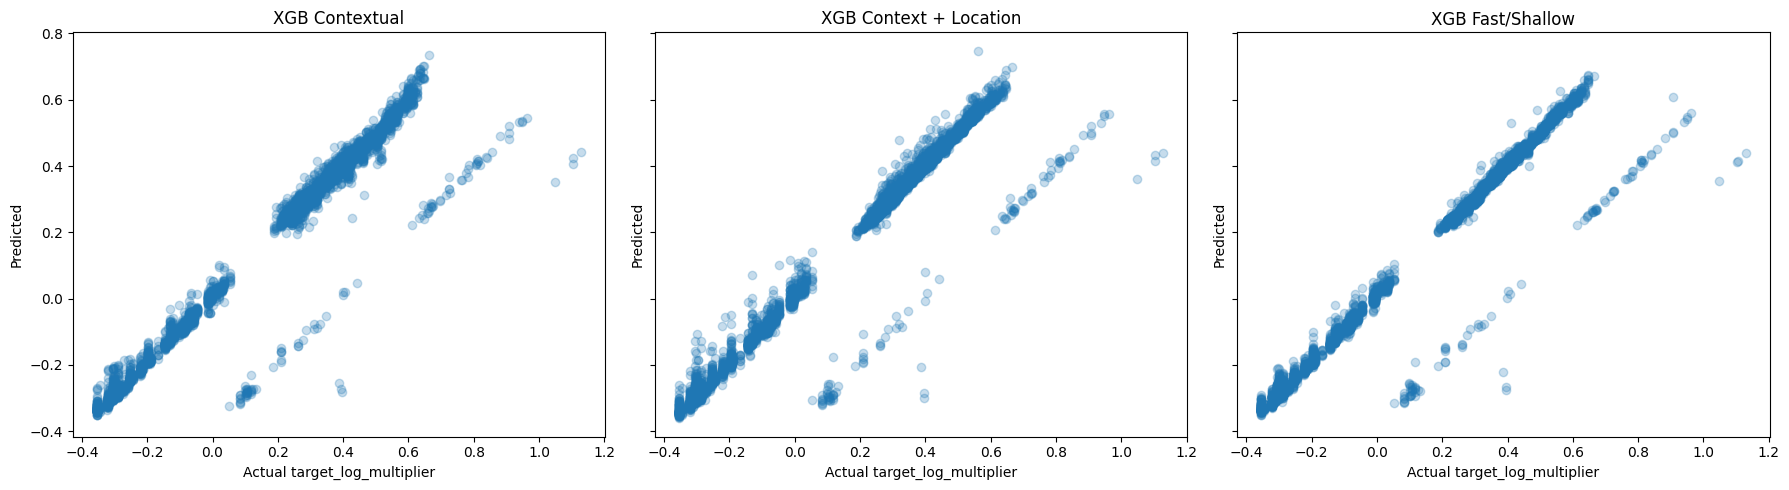

In [152]:
# Compare actual vs predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, result in zip(
    axes,
    [context_result, location_result, fast_result]
):
    ax.scatter(result["y_test"], result["preds"], alpha=0.25)
    ax.set_title(result["label"])
    ax.set_xlabel("Actual target_log_multiplier")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

## Feature importance

This uses the fitted XGBoost importance scores. These are useful for understanding which variables are driving the continuous propensity adjustment.

In [153]:
best_label = results_df.iloc[0]["model"]

best_result = {
    context_result["label"]: context_result,
    location_result["label"]: location_result,
    fast_result["label"]: fast_result,
}[best_label]

print("Best model by RMSE:", best_label)

Best model by RMSE: XGB Fast/Shallow


<Figure size 1000x800 with 0 Axes>

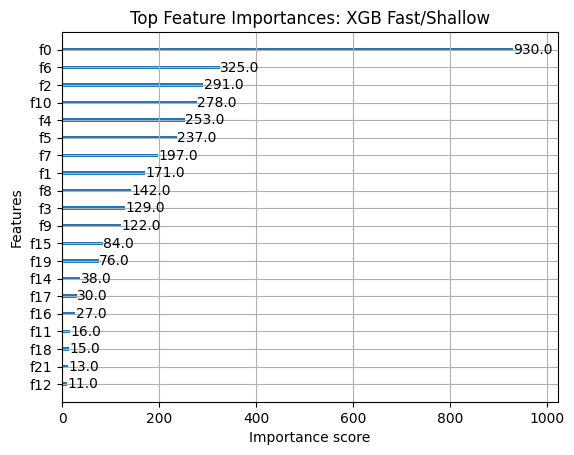

In [154]:
plt.figure(figsize=(10, 8))
plot_importance(best_result["model"], max_num_features=20)
plt.title(f"Top Feature Importances: {best_result['label']}")
plt.show()

In [155]:
print(pd.DataFrame({
    "xgb_name": [f"f{i}" for i in range(len(fast_features))],
    "actual_name": fast_features
}))

   xgb_name                actual_name
0        f0                       hour
1        f1                  dayofweek
2        f2                       temp
3        f3                     precip
4        f4                 cloudcover
5        f5                   humidity
6        f6                  windspeed
7        f7           trees_within_50m
8        f8             env_within_50m
9        f9         min_station_dist_m
10      f10            nearest_station
11      f11                   day_type
12      f12  station_overall_ridership


## Convert predictions into ABM-ready probabilities

The model predicts `target_log_multiplier`. To convert that into the probability used in the ABM:

1. exponentiate the predicted log multiplier
2. multiply by the baseline probability
3. clip the result to `[0,1]`
4. apply the hard CMPD override outside the model

In [156]:
# ABM-ready probability conversion on the test set for the best model
test_eval = test_df.copy()
test_eval["pred_log_multiplier"] = best_result["preds"]
test_eval["pred_multiplier"] = np.exp(test_eval["pred_log_multiplier"])
test_eval["pred_final_prob"] = np.clip(
    test_eval["baseline_prob"] * test_eval["pred_multiplier"],
    0,
    1
)

test_eval[[
    "date_only", "hour", "nearest_station",
    "baseline_prob", "pred_log_multiplier",
    "pred_multiplier", "pred_final_prob"
]].head(10)

,date_only,hour,nearest_station,baseline_prob,pred_log_multiplier,pred_multiplier,pred_final_prob
17,2025-07-29,22,East/West,0.309904,0.372925,1.451975,0.449973
18,2025-10-16,3,East/West,0.164200,0.527155,1.694106,0.278173
69,2025-09-20,9,East/West,0.455189,0.239344,1.270415,0.578279
70,2025-12-02,12,East/West,0.418668,0.266718,1.305672,0.546643
71,2026-01-01,13,East/West,0.417722,0.258951,1.295570,0.541189
72,2026-02-09,17,East/West,0.375901,0.305155,1.356835,0.510035
342,2024-08-02,15,East/West,0.442577,0.220554,1.246767,0.551790
343,2024-08-02,22,East/West,0.309904,0.370897,1.449033,0.449062
344,2024-08-14,14,East/West,0.426180,0.250178,1.284254,0.547323
345,2024-08-15,10,East/West,0.414876,0.262767,1.300523,0.539555


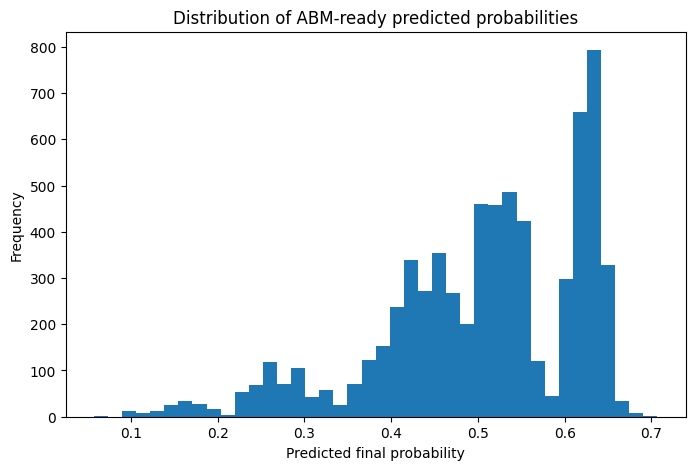

In [157]:
plt.figure(figsize=(8, 5))
plt.hist(test_eval["pred_final_prob"], bins=40)
plt.xlabel("Predicted final probability")
plt.ylabel("Frequency")
plt.title("Distribution of ABM-ready predicted probabilities")
plt.show()

## Save the best fitted model inputs

This cell saves a comparison table and a scored test set.  
The notebook does not serialize the full pipeline object, but that can be added later if you want a deployable model artifact.

In [158]:
#results_df.to_csv("xgboost_model_comparison.csv", index=False)
#test_eval.to_csv("xgboost_scored_test_set.csv", index=False)

print("Saved: xgboost_model_comparison.csv")
print("Saved: xgboost_scored_test_set.csv")

Saved: xgboost_model_comparison.csv
Saved: xgboost_scored_test_set.csv


## Recommended next step

If the fast/shallow model performs close to the larger models, it may be the better ABM choice because it will be called many times in the simulation. If the larger location-aware model meaningfully improves fit, then it may be worth using that one and later testing whether a distilled decision tree or lookup approximation can preserve most of its behavior at lower runtime cost.